In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Import thư viện thành công")

Import thư viện thành công


cell 2 upload dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

đọc dữ liệu

In [ ]:
df = pd.read_csv("7_wind_turbine_performance.csv")

df.head()

kiểm tra tổng quan dữ liệu

In [ ]:
print("Số dòng, số cột:", df.shape)

print("\nTên các cột:")
print(df.columns.tolist())

print("\nKiểu dữ liệu:")
print(df.dtypes)

kiểm tra NULL

In [ ]:
print("Missing values:")
print(df.isnull().sum())

kiểm tra các dòng

In [ ]:
print("Số dòng bị trùng:", df.duplicated().sum())

Thống kê các cột số

In [ ]:
df.describe().T

kiểm tra các cột dạng chữ

In [ ]:
categorical_cols = [
    "region",
    "turbine_id",
    "maintenance_status",
    "technician_note"
]

for col in categorical_cols:
    print("\n======================")
    print("Cột:", col)
    print("Số giá trị khác nhau:", df[col].nunique())
    print(df[col].value_counts().head(20))

kiểm tra các giá trị vô lý

In [ ]:
checks = {
    "wind_speed < 0":
        (df["wind_speed"] < 0).sum(),

    "wind_direction ngoài [0, 360]":
        ((df["wind_direction"] < 0) |
         (df["wind_direction"] > 360)).sum(),

    "air_density <= 0":
        (df["air_density"] <= 0).sum(),

    "generator_efficiency ngoài [0, 1]":
        ((df["generator_efficiency"] < 0) |
         (df["generator_efficiency"] > 1)).sum(),

    "humidity ngoài [0, 100]":
        ((df["humidity"] < 0) |
         (df["humidity"] > 100)).sum(),

    "power_output < 0":
        (df["power_output"] < 0).sum()
}

for name, value in checks.items():
    print(name, ":", value)

kiểm tra power ouput = 0

In [ ]:
zero_power = (df["power_output"] == 0).sum()

print("Số dòng power_output = 0:", zero_power)
print(
    "Tỷ lệ:",
    round(zero_power / len(df) * 100, 2),
    "%"
)

tìm nguyên nhân power_output = 0

In [ ]:
# So sánh các dòng power_output = 0 và > 0

print("=== POWER = 0 ===")
print(
    df[df["power_output"] == 0][
        ["wind_speed", "rotor_speed", "generator_efficiency"]
    ].describe()
)

print("\n=== POWER > 0 ===")
print(
    df[df["power_output"] > 0][
        ["wind_speed", "rotor_speed", "generator_efficiency"]
    ].describe()
)

check power = 0 có liên quan bảo trì không

In [ ]:
zero_by_status = df.groupby("maintenance_status").agg(
    total=("power_output", "size"),
    zero_power=("power_output", lambda x: (x == 0).sum())
)

zero_by_status["zero_percent"] = (
    zero_by_status["zero_power"]
    / zero_by_status["total"]
    * 100
)

zero_by_status

công suất 0 theo tốc độ gió

In [ ]:
bins = [0, 3, 5, 10, 15, 20, 25, 30]

df["wind_speed_group"] = pd.cut(
    df["wind_speed"],
    bins=bins
)

zero_by_wind = df.groupby(
    "wind_speed_group",
    observed=True
).agg(
    total=("power_output", "size"),
    zero_power=("power_output", lambda x: (x == 0).sum())
)

zero_by_wind["zero_percent"] = (
    zero_by_wind["zero_power"]
    / zero_by_wind["total"]
    * 100
)

zero_by_wind

kiểm tra outlier

In [ ]:
numeric_cols = [
    "wind_speed",
    "wind_direction",
    "air_density",
    "temperature",
    "blade_angle",
    "rotor_speed",
    "generator_efficiency",
    "altitude",
    "humidity",
    "power_output"
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(
        f"{col:25s} | "
        f"Outlier: {outliers:6d} | "
        f"{outliers/len(df)*100:.2f}%"
    )

cell 15

In [ ]:
Q1 = df["power_output"].quantile(0.25)
Q3 = df["power_output"].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

power_outliers = df[df["power_output"] > upper]

print("Ngưỡng outlier:", upper)
print("Số outlier:", len(power_outliers))

power_outliers[
    [
        "wind_speed",
        "air_density",
        "generator_efficiency",
        "rotor_speed",
        "power_output"
    ]
].describe()

20 dòng cao nhất

In [ ]:
power_outliers[
    [
        "wind_speed",
        "air_density",
        "generator_efficiency",
        "rotor_speed",
        "power_output"
    ]
].sort_values(
    "power_output",
    ascending=False
).head(20)

chạy lại cell 16 cái data clean

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

save_path = "/content/drive/MyDrive/wind_turbine_project"

df = pd.read_csv(f"{save_path}/wind_turbine_cleaned.csv")

print(df.shape)
df.head()

Mounted at /content/drive
(187923, 15)


,record_id,region,turbine_id,wind_speed,wind_direction,air_density,temperature,blade_angle,rotor_speed,generator_efficiency,maintenance_status,technician_note,altitude,humidity,power_output
0,1,Plains,TB0051,13.444284,81.850989,1.185040,16.150543,12.283854,22.738306,0.893632,Normal,Lubrication check,1499.354658,40.570236,29.152132
1,2,Offshore,TB0004,20.786844,17.811681,1.248615,-2.559741,15.731588,16.404483,0.970845,Normal,Minor vibration,964.155726,80.384438,46.370431
2,3,Coastal,TB0018,9.877894,139.904348,1.122320,33.850505,19.360882,18.398903,0.877584,Normal,Minor vibration,1240.710840,80.416293,0.000000
3,4,Plains,TB0002,9.981482,146.949240,1.296619,38.533935,19.420923,16.818615,0.877823,Normal,Noise detected,1150.442670,58.523295,0.000000
4,5,Plains,TB0058,22.998714,144.567335,1.152582,19.650483,11.723532,6.714416,0.872402,Normal,Minor vibration,1041.622776,79.883516,11.014005


Cell 17 — xóa cột tạm lúc kiểm tra

In [ ]:
if "wind_speed_group" in df.columns:
    df.drop(columns=["wind_speed_group"], inplace=True)

print(df.shape)

xác định target và bỏ cột không có ý nghĩa học máy

In [ ]:
target = "power_output"

X = df.drop(columns=["record_id", target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (187923, 13)
y shape: (187923,)

Features:
['region', 'turbine_id', 'wind_speed', 'wind_direction', 'air_density', 'temperature', 'blade_angle', 'rotor_speed', 'generator_efficiency', 'maintenance_status', 'technician_note', 'altitude', 'humidity']


chia Train / Validation / Test 70-15-15

In [ ]:
from sklearn.model_selection import train_test_split

# Nhãn phụ chỉ dùng để giữ tỷ lệ power = 0 giữa các tập
zero_flag = (y == 0).astype(int)

# 70% train, 30% tạm
X_train, X_temp, y_train, y_temp, flag_train, flag_temp = train_test_split(
    X,
    y,
    zero_flag,
    test_size=0.30,
    random_state=42,
    stratify=zero_flag
)

# 30% còn lại chia đôi -> 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=flag_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (131546, 13) (131546,)
Validation: (28188, 13) (28188,)
Test: (28189, 13) (28189,)


kiểm tra tỷ lệ power_output = 0

In [ ]:
def check_zero_ratio(name, y_data):
    zero_count = (y_data == 0).sum()
    zero_percent = zero_count / len(y_data) * 100

    print(
        f"{name:12s}: "
        f"{len(y_data):6d} dòng | "
        f"power=0: {zero_percent:.2f}%"
    )

check_zero_ratio("Train", y_train)
check_zero_ratio("Validation", y_val)
check_zero_ratio("Test", y_test)

xem tương quan các feature số trên Train

In [ ]:
train_analysis = X_train.copy()
train_analysis["power_output"] = y_train

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

correlation = (
    train_analysis[numeric_features + ["power_output"]]
    .corr()["power_output"]
    .drop("power_output")
    .sort_values(key=abs, ascending=False)
)

print(correlation)

kiểm tra các feature dạng chữ

In [ ]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Các categorical features:")
print(categorical_features)

for col in categorical_features:
    print("\n==============================")
    print("Feature:", col)
    print("Số giá trị:", X_train[col].nunique())

    temp = train_analysis.groupby(col)["power_output"].agg(
        ["count", "mean", "median"]
    )

    print(
        temp.sort_values(
            "mean",
            ascending=False
        ).head(10)
    )

kiểm tra danh sách feature hiện tại

In [ ]:
print("Numeric:")
print(numeric_features)

print("\nCategorical:")
print(categorical_features)

print("\nTổng số feature gốc:",
      len(numeric_features) + len(categorical_features))

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

In [ ]:
import os

save_path = "/content/drive/MyDrive/wind_turbine_project"
os.makedirs(save_path, exist_ok=True)

print("Thư mục lưu:", save_path)

lưu dataset đã kiểm tra sạch

In [ ]:
df.to_csv(
    f"{save_path}/wind_turbine_cleaned.csv",
    index=False
)

print("Đã lưu cleaned dataset")

lưu Train / Validation / Test

In [ ]:
train_data = X_train.copy()
train_data["power_output"] = y_train

val_data = X_val.copy()
val_data["power_output"] = y_val

test_data = X_test.copy()
test_data["power_output"] = y_test

train_data.to_csv(
    f"{save_path}/train.csv",
    index=False
)

val_data.to_csv(
    f"{save_path}/validation.csv",
    index=False
)

test_data.to_csv(
    f"{save_path}/test.csv",
    index=False
)

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

bắt đầu tiền xử lý

chia feature số và categorical

In [ ]:
numeric_features = [
    "wind_speed",
    "wind_direction",
    "air_density",
    "temperature",
    "blade_angle",
    "rotor_speed",
    "generator_efficiency",
    "altitude",
    "humidity"
]

categorical_features = [
    "region",
    "turbine_id",
    "maintenance_status",
    "technician_note"
]

print("Numeric:", len(numeric_features))
print(numeric_features)

print("\nCategorical:", len(categorical_features))
print(categorical_features)

Numeric: 9
['wind_speed', 'wind_direction', 'air_density', 'temperature', 'blade_angle', 'rotor_speed', 'generator_efficiency', 'altitude', 'humidity']

Categorical: 4
['region', 'turbine_id', 'maintenance_status', 'technician_note']


tạo bộ tiền xử lý
Feature số → StandardScaler
Feature chữ → OneHotEncoder

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Đã tạo preprocessing pipeline")

Đã tạo preprocessing pipeline


FIT chỉ trên Train

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

print("Train processed:", X_train_processed.shape)
print("Validation processed:", X_val_processed.shape)
print("Test processed:", X_test_processed.shape)

Train processed: (131546, 80)
Validation processed: (28188, 80)
Test processed: (28189, 80)


kiểm tra số feature sau encode

In [ ]:
feature_names = preprocessor.get_feature_names_out()

print("Số feature sau preprocessing:", len(feature_names))

print("\n20 feature đầu:")
print(feature_names[:20])

Số feature sau preprocessing: 80

20 feature đầu:
['num__wind_speed' 'num__wind_direction' 'num__air_density'
 'num__temperature' 'num__blade_angle' 'num__rotor_speed'
 'num__generator_efficiency' 'num__altitude' 'num__humidity'
 'cat__region_Coastal' 'cat__region_Mountain' 'cat__region_Offshore'
 'cat__region_Plains' 'cat__turbine_id_TB0001' 'cat__turbine_id_TB0002'
 'cat__turbine_id_TB0003' 'cat__turbine_id_TB0004'
 'cat__turbine_id_TB0005' 'cat__turbine_id_TB0006'
 'cat__turbine_id_TB0007']


kiểm tra dữ liệu sau preprocessing có NaN/Inf không

In [ ]:
import numpy as np

def check_processed(name, X):
    X_array = X.toarray() if hasattr(X, "toarray") else X

    print(f"{name}:")
    print("  NaN:", np.isnan(X_array).sum())
    print("  Inf:", np.isinf(X_array).sum())
    print("  Shape:", X_array.shape)

check_processed("Train", X_train_processed)
check_processed("Validation", X_val_processed)
check_processed("Test", X_test_processed)

Train:
  NaN: 0
  Inf: 0
  Shape: (131546, 80)
Validation:
  NaN: 0
  Inf: 0
  Shape: (28188, 80)
Test:
  NaN: 0
  Inf: 0
  Shape: (28189, 80)


lưu lại preprocesssing

In [ ]:
import joblib

joblib.dump(
    preprocessor,
    f"{save_path}/preprocessor.pkl"
)

print("Đã lưu preprocessor.pkl")

Đã lưu preprocessor.pkl


lưu lại train val test

In [ ]:
train_data = X_train.copy()
train_data["power_output"] = y_train

val_data = X_val.copy()
val_data["power_output"] = y_val

test_data = X_test.copy()
test_data["power_output"] = y_test

train_data.to_csv(f"{save_path}/train.csv", index=False)
val_data.to_csv(f"{save_path}/validation.csv", index=False)
test_data.to_csv(f"{save_path}/test.csv", index=False)

print("Đã lưu train / validation / test")

Đã lưu train / validation / test


Bảng thống kê

In [ ]:
summary = pd.DataFrame({
    "Thông tin": [
        "Số bản ghi",
        "Số cột ban đầu",
        "Missing values",
        "Duplicate rows",
        "Target",
        "Power output = 0",
        "Tỷ lệ power output = 0"
    ],
    "Giá trị": [
        len(df),
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        "power_output",
        (df["power_output"] == 0).sum(),
        f'{(df["power_output"] == 0).mean()*100:.2f}%'
    ]
})

summary

,Thông tin,Giá trị
0,Số bản ghi,187923
1,Số cột ban đầu,15
2,Missing values,0
3,Duplicate rows,0
4,Target,power_output
5,Power output = 0,51651
6,Tỷ lệ power output = 0,27.49%


lưu dataset tổng quan

In [ ]:
summary.to_csv(
    f"{save_path}/dataset_summary.csv",
    index=False
)

bảng 2: thống kê các biến số:

In [ ]:
numeric_summary = df[
    [
        "wind_speed",
        "wind_direction",
        "air_density",
        "temperature",
        "blade_angle",
        "rotor_speed",
        "generator_efficiency",
        "altitude",
        "humidity",
        "power_output"
    ]
].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
wind_speed,187923.0,13.497740,6.642833,2.000051,7.732633,13.491087,19.248968,24.999876
wind_direction,187923.0,180.162658,103.743611,0.000187,90.533623,180.296858,269.813075,359.999393
air_density,187923.0,1.199990,0.057701,1.100001,1.150174,1.199826,1.249992,1.299999
temperature,187923.0,17.538688,13.003660,-4.999963,6.252721,17.580925,28.798316,39.999677
blade_angle,187923.0,14.992864,8.659558,0.000015,7.489901,14.976370,22.493972,29.999933
rotor_speed,187923.0,14.985012,5.768203,5.000065,9.987016,14.965796,19.972453,24.999839
generator_efficiency,187923.0,0.914891,0.037466,0.850000,0.882539,0.914899,0.947317,0.979999
altitude,187923.0,749.603479,432.391465,0.007667,375.540085,750.027750,1123.094337,1499.998757
humidity,187923.0,57.514152,21.639749,20.000613,38.813292,57.519754,76.236735,94.999352
power_output,187923.0,21.307123,22.314244,0.000000,0.000000,15.422470,34.881275,136.801494


Lưu bảng 2

In [ ]:
numeric_summary.to_csv(
    f"{save_path}/numeric_summary.csv"
)

Biểu đồ Wind Speed vs Power Output

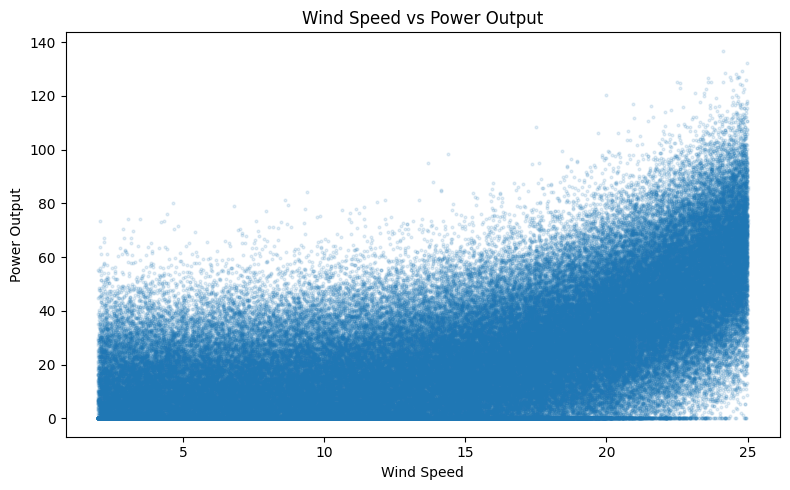

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["wind_speed"],
    df["power_output"],
    alpha=0.12,
    s=4
)

plt.xlabel("Wind Speed")
plt.ylabel("Power Output")
plt.title("Wind Speed vs Power Output")

plt.tight_layout()

plt.savefig(
    f"{save_path}/wind_speed_vs_power.png",
    dpi=300
)

plt.show()

phân bố Power Output:

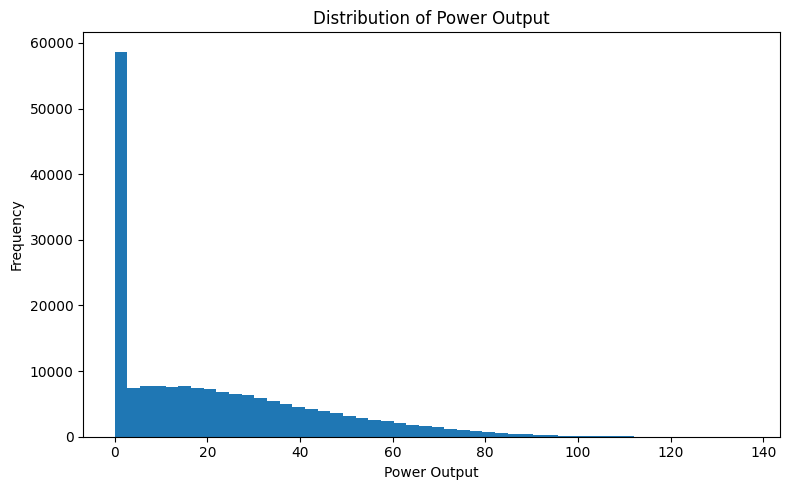

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["power_output"],
    bins=50
)

plt.xlabel("Power Output")
plt.ylabel("Frequency")
plt.title("Distribution of Power Output")

plt.tight_layout()

plt.savefig(
    f"{save_path}/power_output_distribution.png",
    dpi=300
)

plt.show()

biểu đồ tỷ lệ power = 0 theo tốc độ gió

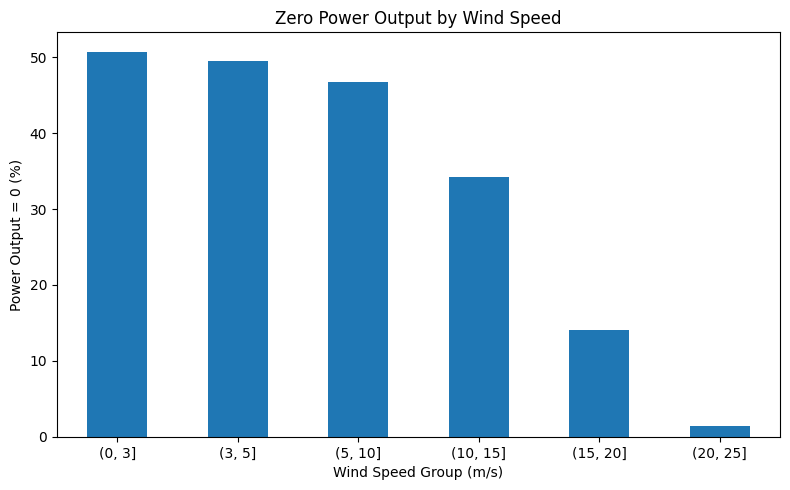

In [ ]:
bins = [0, 3, 5, 10, 15, 20, 25]

temp = df.copy()

temp["wind_group"] = pd.cut(
    temp["wind_speed"],
    bins=bins
)

zero_by_wind = temp.groupby(
    "wind_group",
    observed=True
)["power_output"].apply(
    lambda x: (x == 0).mean() * 100
)

plt.figure(figsize=(8, 5))

zero_by_wind.plot(kind="bar")

plt.xlabel("Wind Speed Group (m/s)")
plt.ylabel("Power Output = 0 (%)")
plt.title("Zero Power Output by Wind Speed")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    f"{save_path}/zero_power_by_wind_speed.png",
    dpi=300
)

plt.show()

correlation với target:

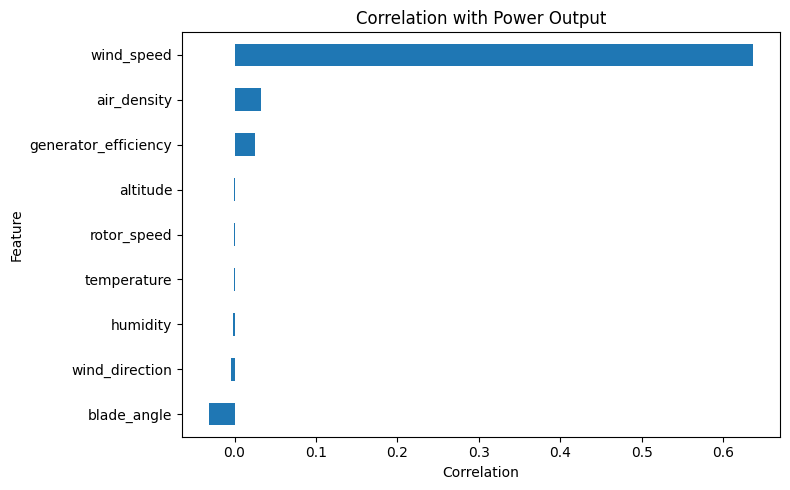

In [ ]:
corr = df.select_dtypes(
    include=np.number
).corr()["power_output"].drop(
    ["power_output", "record_id"]
).sort_values()

plt.figure(figsize=(8, 5))

corr.plot(kind="barh")

plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.title("Correlation with Power Output")

plt.tight_layout()

plt.savefig(
    f"{save_path}/feature_correlation.png",
    dpi=300
)

plt.show()